In [6]:
import os

import nibabel as nib
import numpy as np

from dotenv import load_dotenv
from multipred.plotting import plot_3dims, plot_static_slices
from multipred.data import identify_regions

In [7]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/fsl_thirdlevel"
MNI_TEMPLATE_PATH = f"{PROJECT_PATH}/data/code/FSL_MNI_templates/MNI152_T1_2mm.nii.gz"

### Visual ES

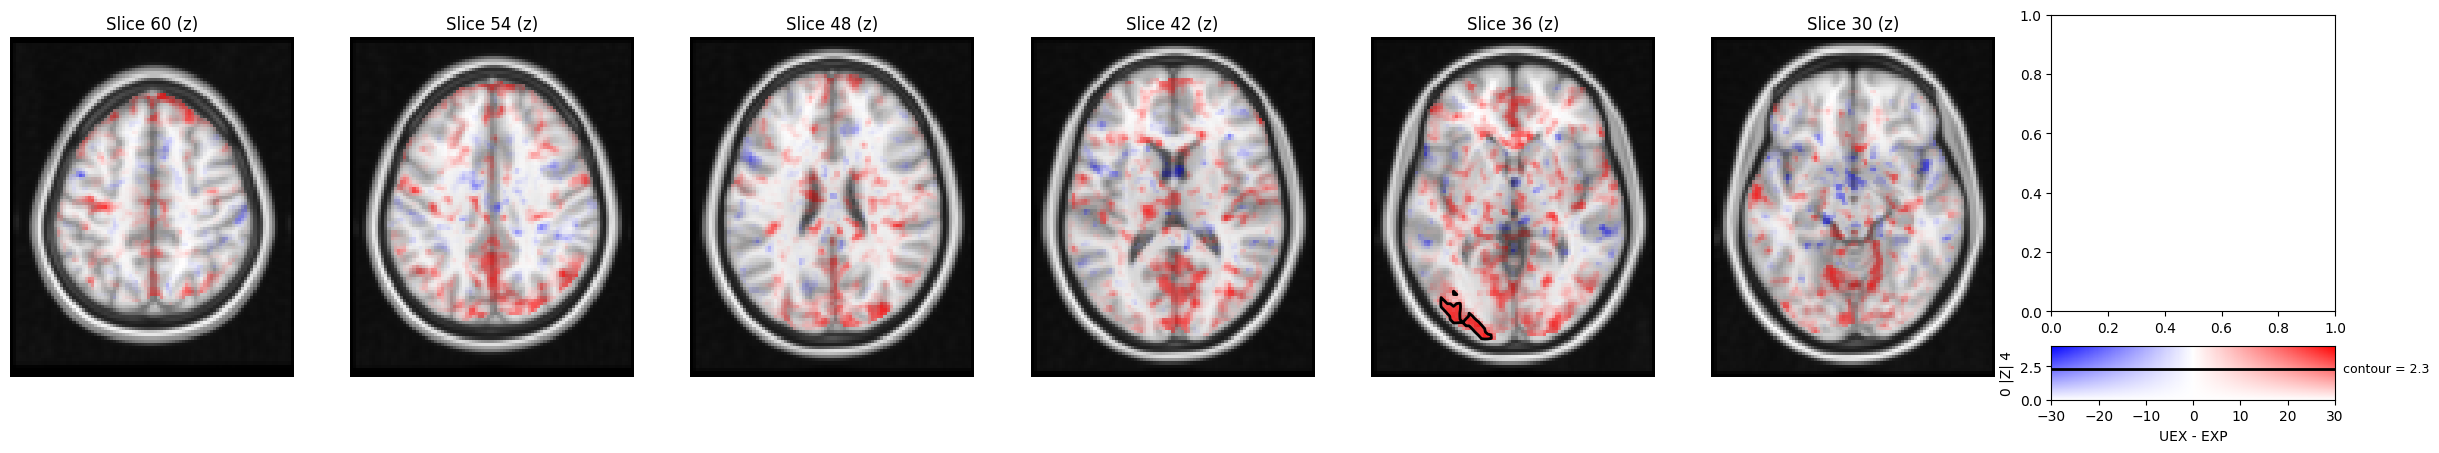

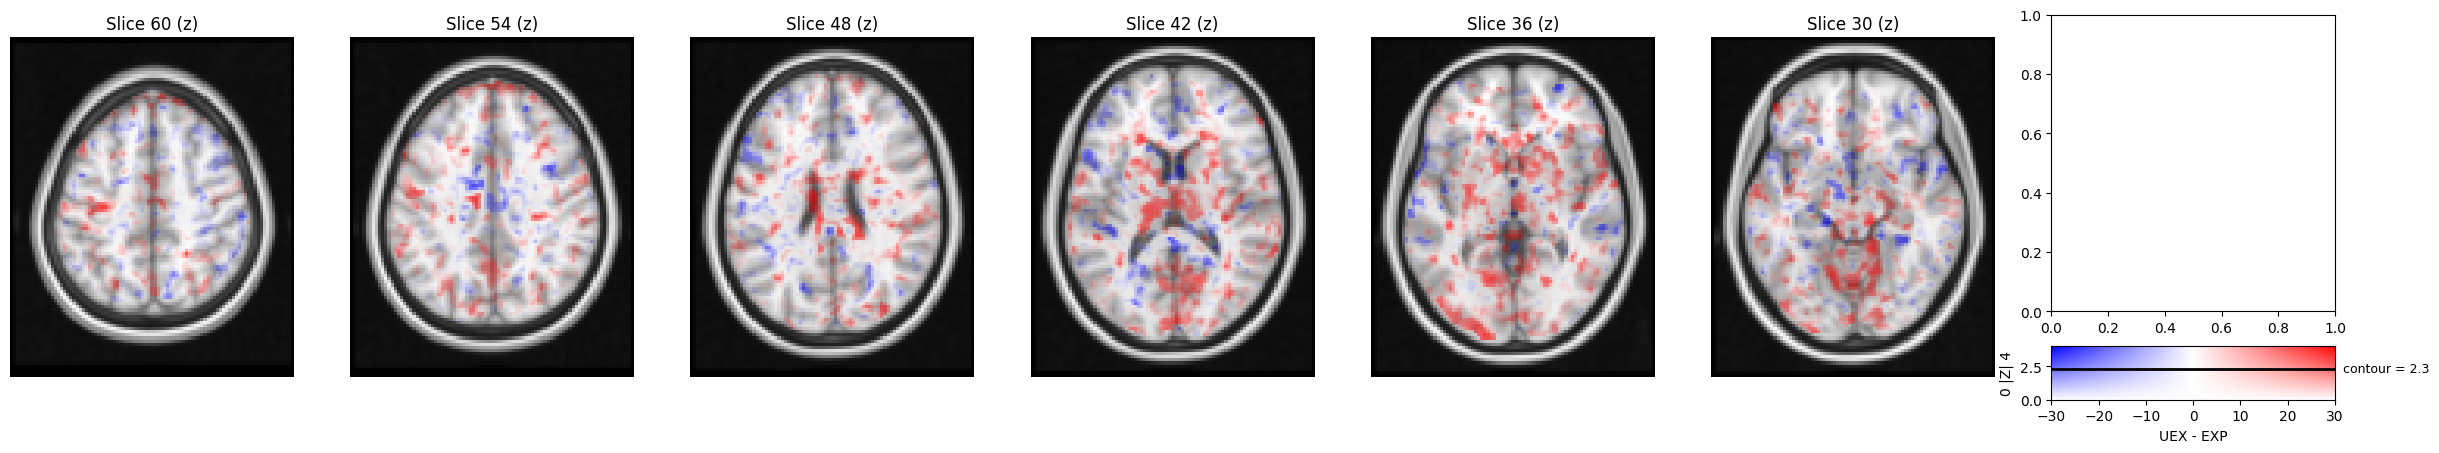

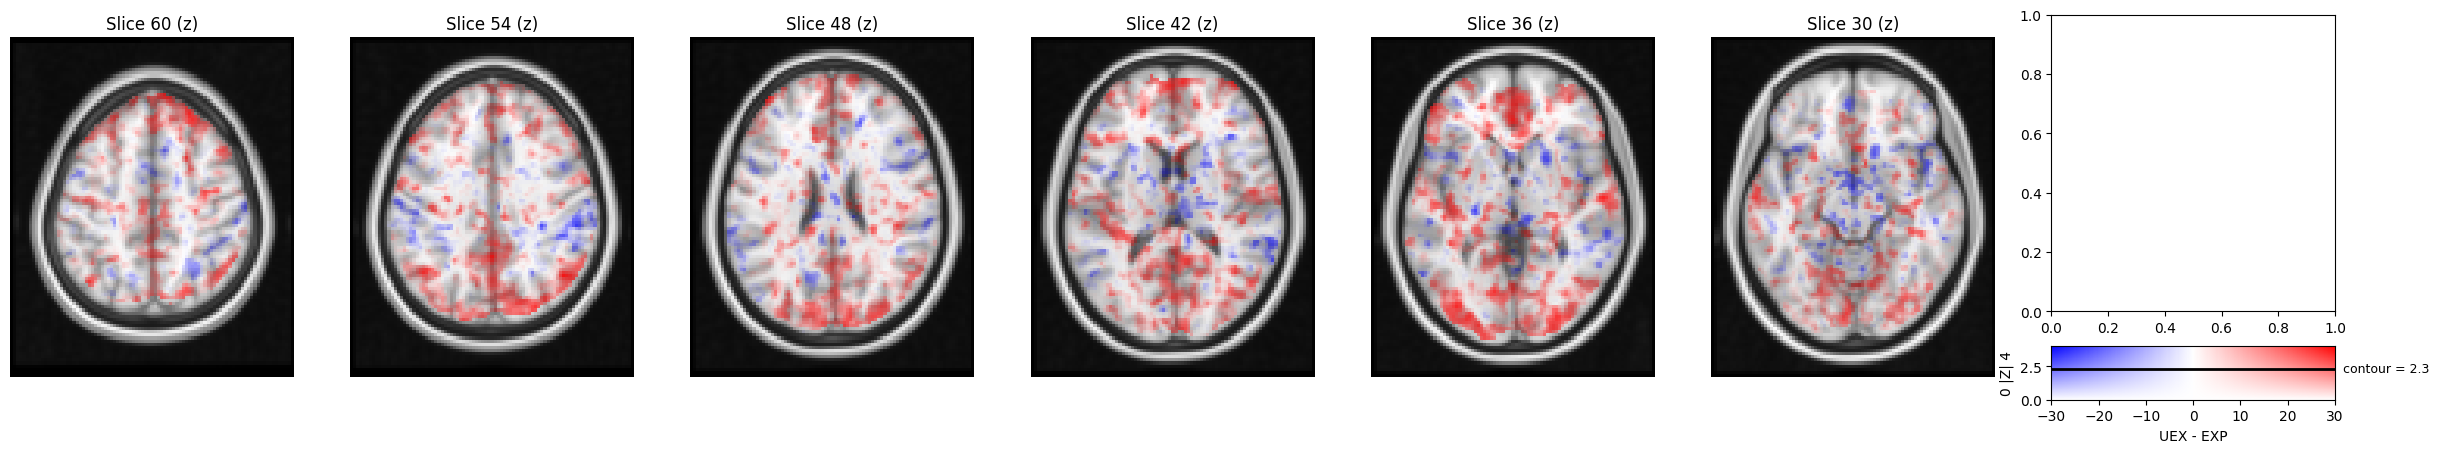

In [8]:
contrast = "visualES" # _aVP" # visualES, visualES_aEXP, visualES_aVP
save_fig = True

for attended_modality, runs_contrast in zip(["all", "visual", "auditory"], ["cope1", "cope2", "cope3"]):

    cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
    abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
    thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"

    if not os.path.exists(abs_zstat_path):
        zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
        zdata = np.abs(zdata)
        abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

    cope_niimg = nib.load(cope_path)
    abs_zstat_niimg = nib.load(abs_zstat_path)
    thresh_zstat_niimg = nib.load(thresh_zstat_path)
    MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

    x, y, z = cope_niimg.get_fdata().shape
    slice_positions = [60, 54, 48, 42, 36, 30]


    fig = plot_static_slices(
        cope=cope_niimg,       # Cope values
        zstat=abs_zstat_niimg,   # Alpha based on zstat values
        z_thresh=thresh_zstat_niimg, # Contours around significant clusters
        mni_template=MNI_template_niimg, # MNI template as base
        slice_positions=slice_positions,
        axis='z',
        clim=(-30, 30),       # Adjust cope value range
        contour_level=2.3,     # Contour level for clusters
        z_lim= [0, 4],
        background='white',    # Background color
        flip_axial=True,       # Flip axial slices
        title=f"Visual UEX - EXP ({attended_modality} runs)"
    )

    if save_fig:
        fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_zslices.svg", dpi=300)

### Auditory ES

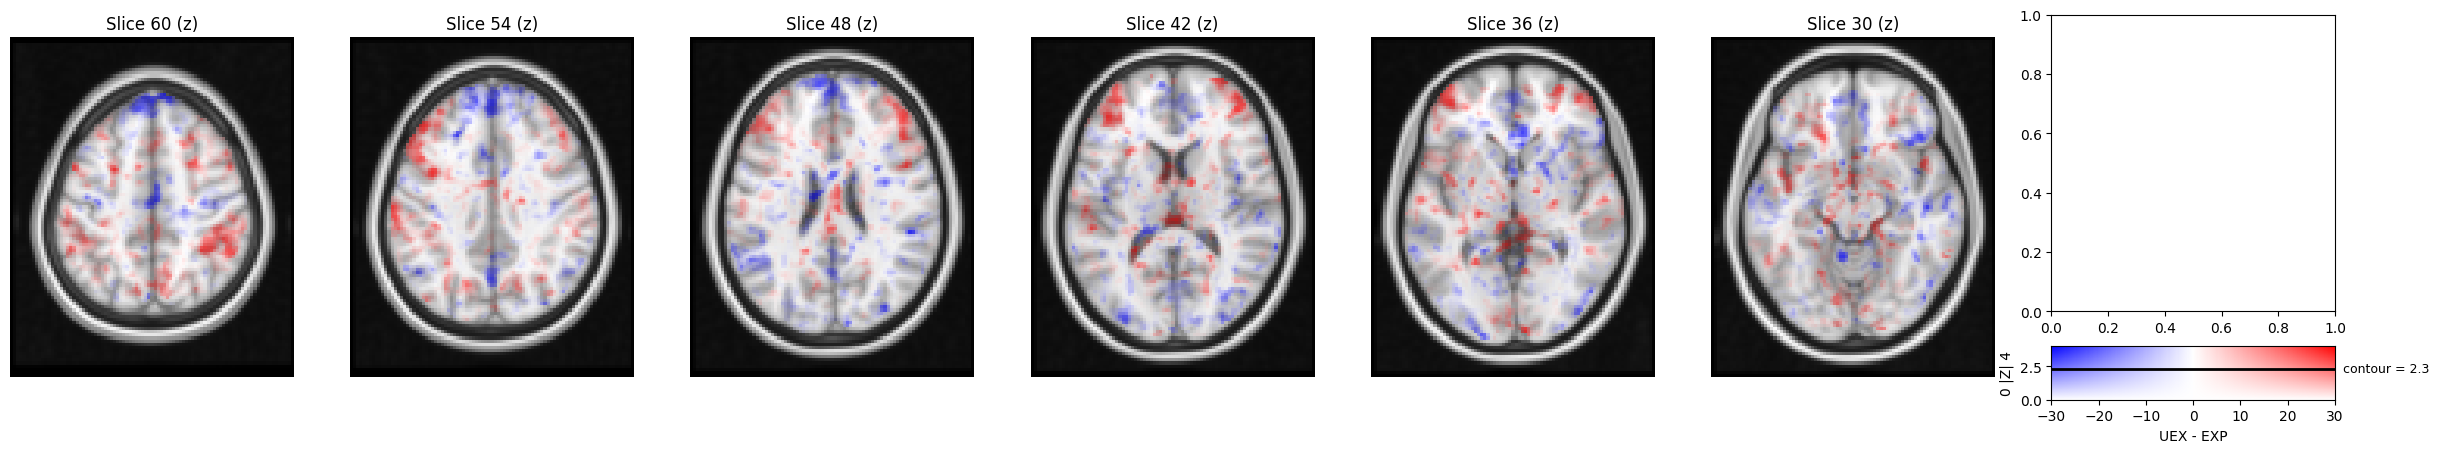

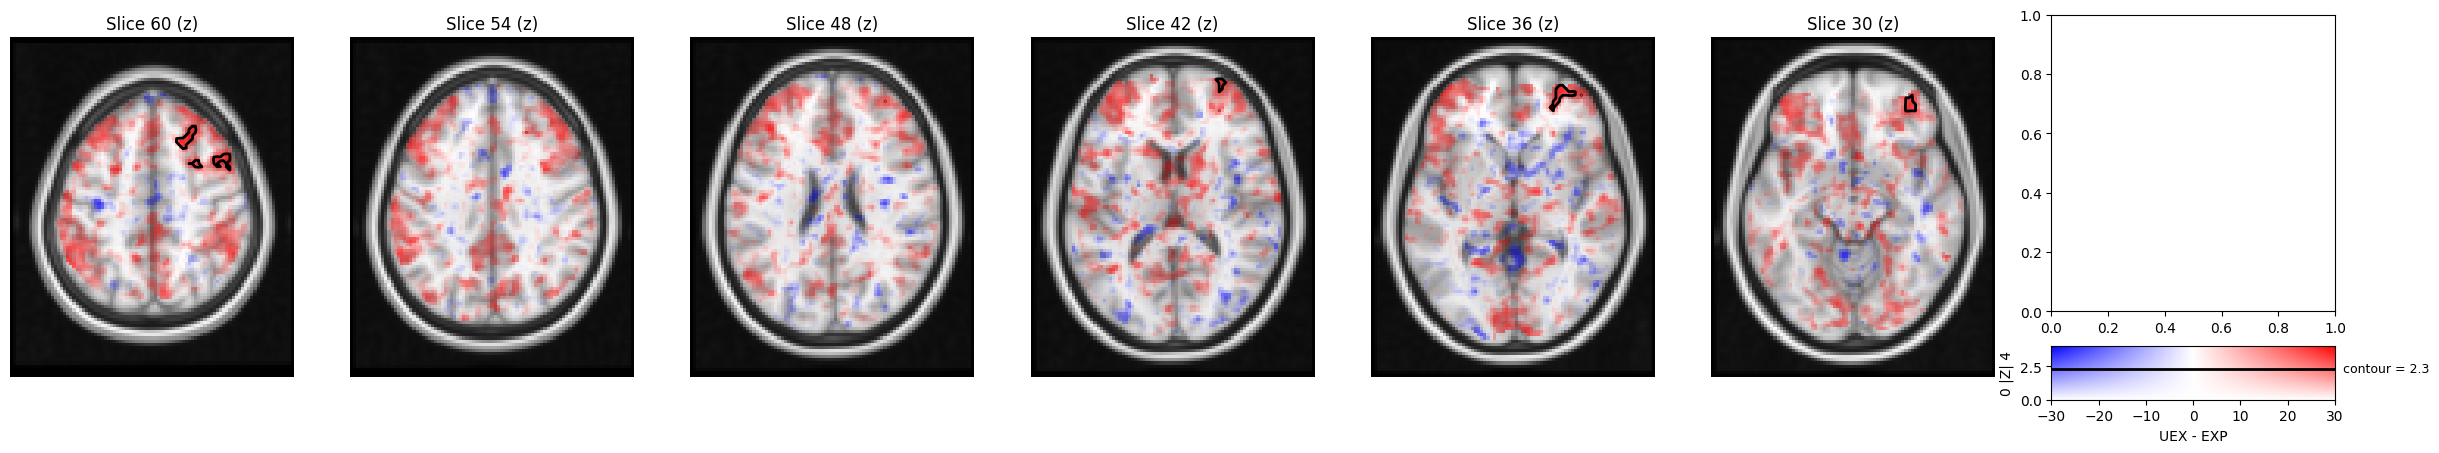

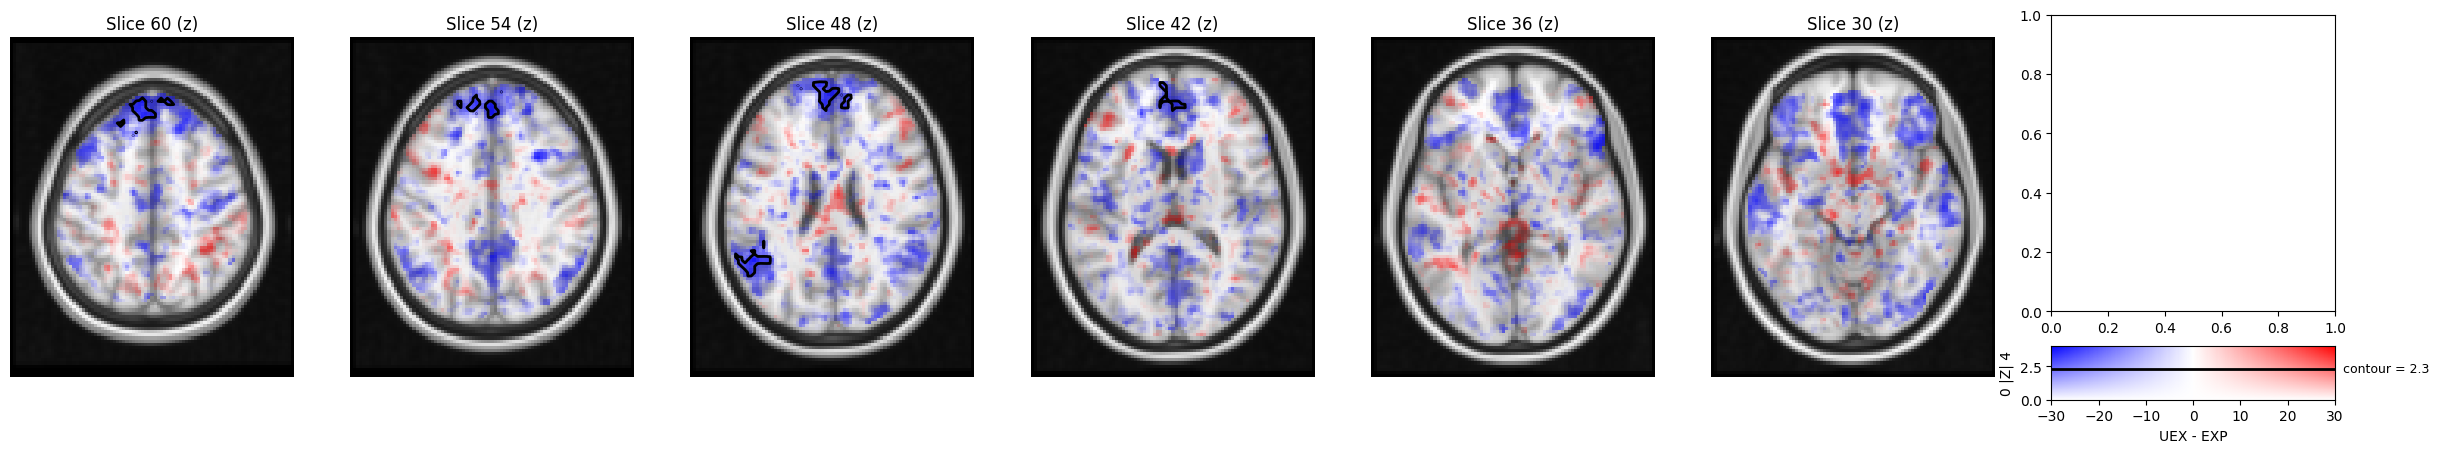

In [4]:
contrast = "auditoryES" # auditoryES, auditoryES_vEXP, auditoryES_vVP
save_fig = False

for attended_modality, runs_contrast in zip(["all", "visual", "auditory"], ["cope1", "cope2", "cope3"]):
    cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
    abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
    thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz"

    if not os.path.exists(abs_zstat_path):
        zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
        zdata = np.abs(zdata)
        abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

    cope_niimg = nib.load(cope_path)
    abs_zstat_niimg = nib.load(abs_zstat_path)
    thresh_zstat_niimg = nib.load(thresh_zstat_path)
    MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

    x, y, z = cope_niimg.get_fdata().shape
    slice_positions =[60, 54, 48, 42, 36, 30]

    fig = plot_static_slices(
        cope=cope_niimg,       # Cope values
        zstat=abs_zstat_niimg,   # Alpha based on zstat values
        z_thresh=thresh_zstat_niimg, # Contours around significant clusters
        mni_template=MNI_template_niimg, # MNI template as base
        slice_positions=slice_positions,
        axis='z',
        clim=(-30, 30),       # Adjust cope value range
        contour_level=2.3,     # Contour level for clusters
        z_lim= [0, 4],
        background='white',    # Background color
        flip_axial=True,       # Flip axial slices
        title=f"Auditory UEX - EXP ({attended_modality} runs)"
    )

    if save_fig:
        if not os.path.exists(f"/media/wiseman/tocho/predrelv_fmri/group_analyses/univariate/FSL/figures/multimodalGLM/{contrast}/"):
            os.makedirs(f"/media/wiseman/tocho/predrelv_fmri/group_analyses/univariate/FSL/figures/multimodalGLM/{contrast}/")
        fig.savefig(f"/media/wiseman/tocho/predrelv_fmri/group_analyses/univariate/FSL/figures/multimodalGLM/{contrast}/{attended_modality}_runs.svg", dpi=300)

## Plot specific clusters

### Visual ES cluster

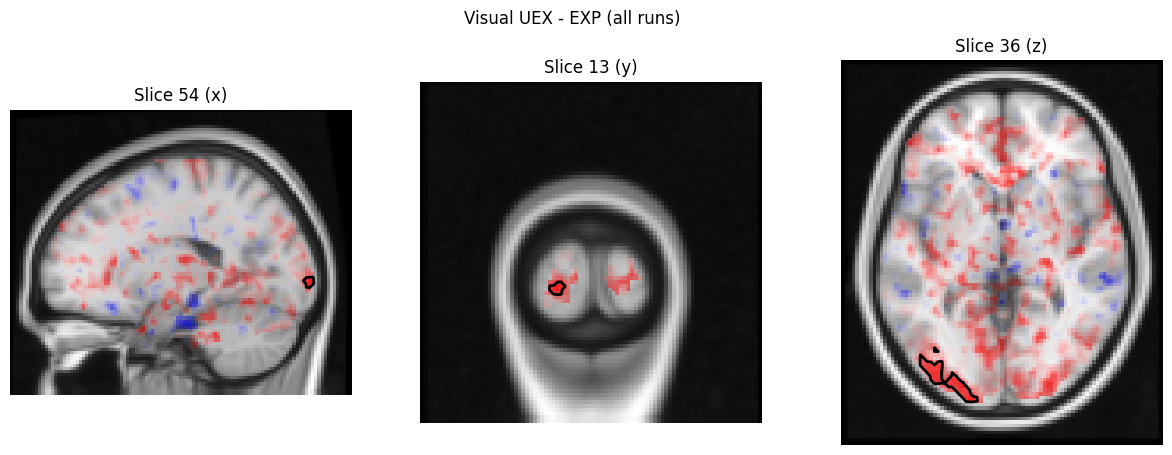

In [5]:
contrast = "visualES"
save_fig = False
runs_contrast, attended_modality = "cope1", "all" # "cope1", "all" # "cope2", "visual" # "cope3", "auditory"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"

if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

coords = [54, 13, 36]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Visual UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster.svg", dpi=300)


In [10]:
identify_regions((-18, -100, 0))

[get_dataset_dir] Dataset found in C:\Users\marcs\nilearn_data\fsl
The MNI coordinate (-18, -100, 0) corresponds to: Occipital Pole


### Auditory ES cluster 1

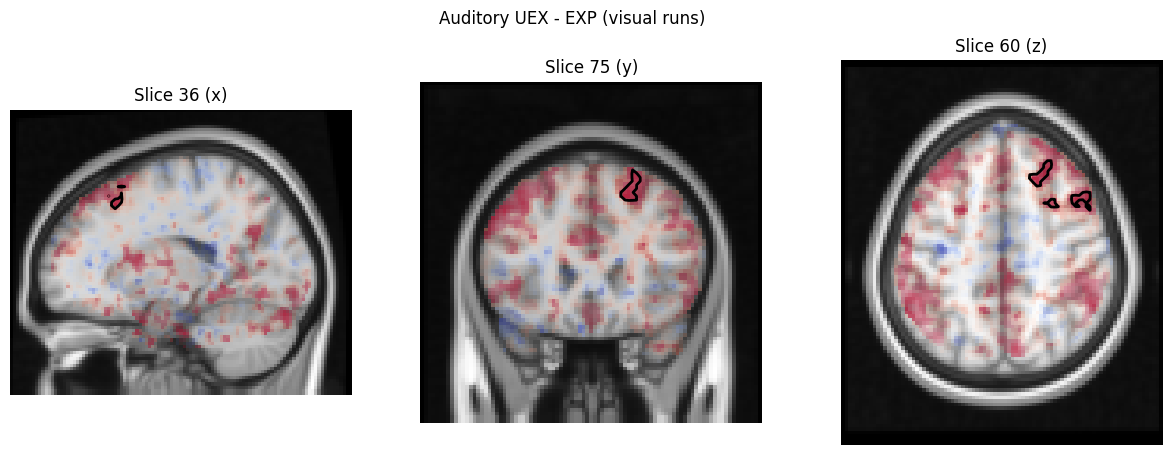

In [5]:
contrast = "auditoryES"
save_fig = False
runs_contrast, attended_modality = "cope2", "visual"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"


if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)


coords = [36, 75, 60]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Auditory UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster.svg", dpi=300)

In [4]:
identify_regions((22, 30, 58))

[get_dataset_dir] Dataset found in C:\Users\marcs\nilearn_data\fsl
The MNI coordinate (22, 30, 58) corresponds to: Superior Frontal Gyrus


In [5]:
identify_regions((30, 64, 12))

[get_dataset_dir] Dataset found in C:\Users\marcs\nilearn_data\fsl
The MNI coordinate (30, 64, 12) corresponds to: Frontal Pole


### Auditory ES cluster 2

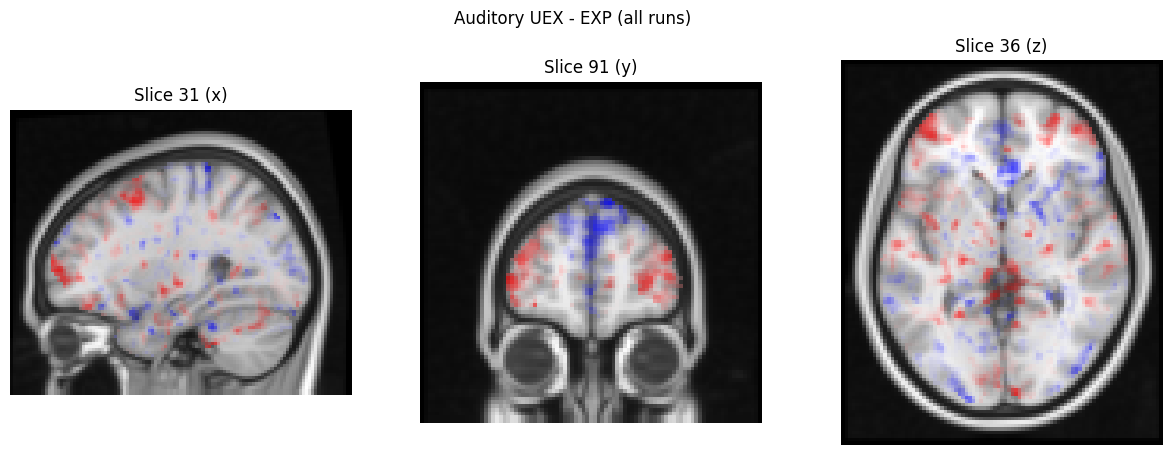

In [7]:
contrast = "auditoryES"
save_fig = True
runs_contrast, attended_modality = "cope1", "all"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"


if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)


#coords = [31, 87, 37]
coords = [31,91,36]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Auditory UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster2.svg", dpi=300)

### Auditory EE cluster 1

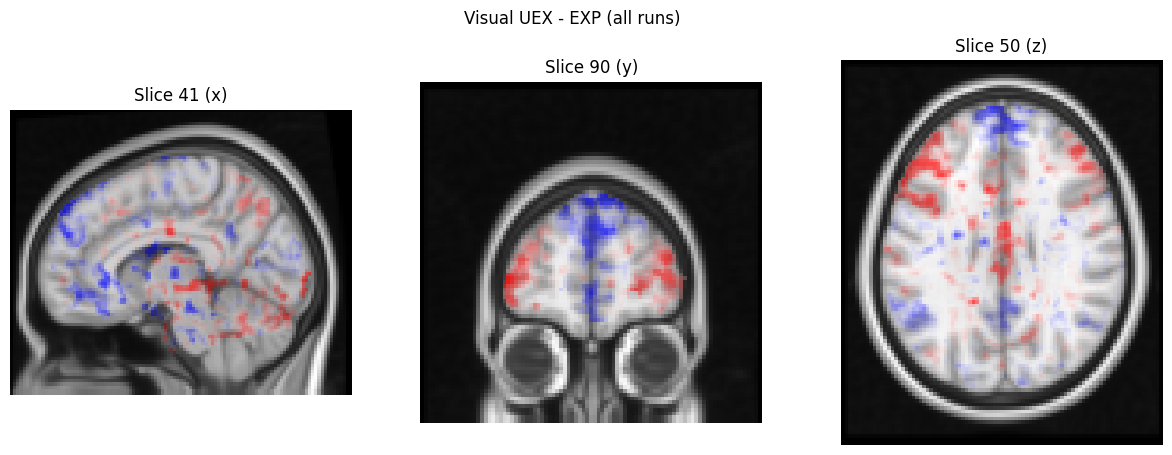

In [20]:
contrast = "auditoryES"
save_fig = False
runs_contrast, attended_modality = "cope1", "all"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"


if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

coords = [41, 90, 50]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Visual UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster.svg", dpi=300)

In [9]:
identify_regions((8, 54, 28))

[get_dataset_dir] Dataset found in C:\Users\marcs\nilearn_data\fsl
The MNI coordinate (8, 54, 28) corresponds to: Superior Frontal Gyrus


In [8]:
identify_regions((-52, -54, 20))

[get_dataset_dir] Dataset found in C:\Users\marcs\nilearn_data\fsl
The MNI coordinate (-52, -54, 20) corresponds to: Angular Gyrus


### Auditory EE cluster 2

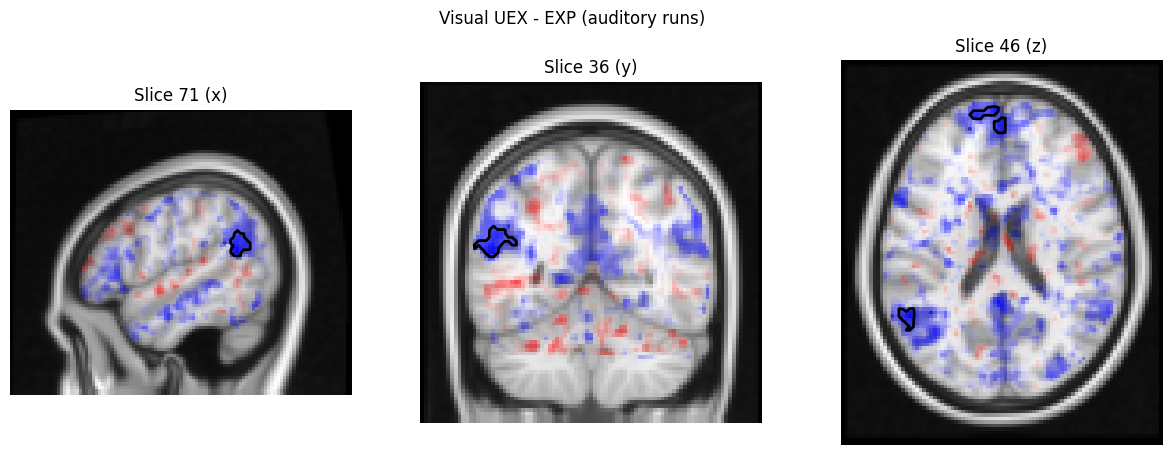

In [3]:
contrast = "auditoryES"
save_fig = False
runs_contrast, attended_modality = "cope3", "auditory"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"


if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

coords = [71, 36, 46]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Visual UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster2.svg", dpi=300)

### Auditory EE cluster combined

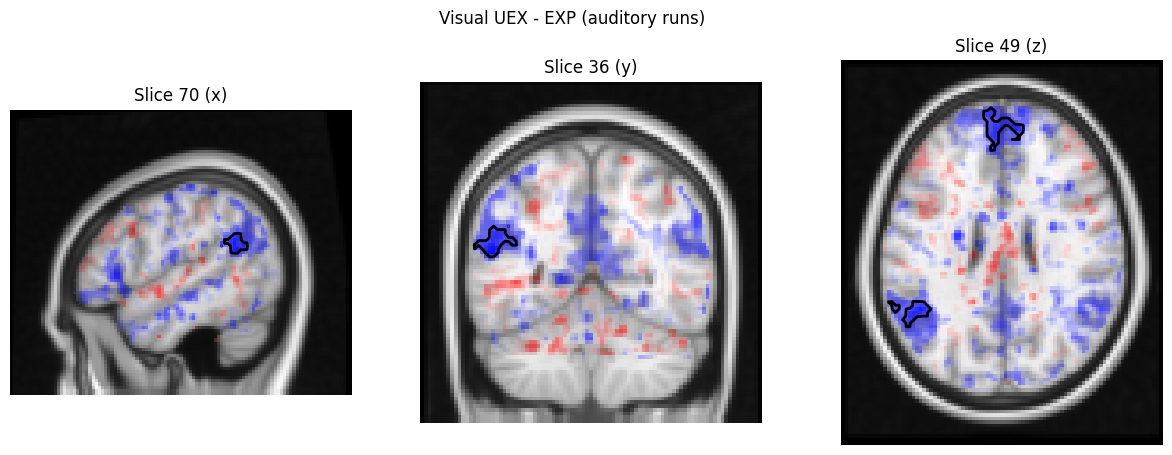

In [4]:
contrast = "auditoryES"
save_fig = False
runs_contrast, attended_modality = "cope3", "auditory"

cope_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/cope1.nii.gz"
abs_zstat_path = f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/abs_zstat1.nii.gz"
thresh_zstat_path = f"{DATA_PATH}/thresh_zstat/{contrast}/{runs_contrast}.nii.gz" #f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}/thresh_zstat1.nii.gz"


if not os.path.exists(abs_zstat_path):
    zdata = nib.load(f"{DATA_PATH}/{contrast}.gfeat/{runs_contrast}.feat/stats/zstat1.nii.gz").get_fdata()
    zdata = np.abs(zdata)
    abs_zstat_img = nib.Nifti1Image(zdata, affine=nib.load(cope_path).affine).to_filename(abs_zstat_path)

cope_niimg = nib.load(cope_path)
abs_zstat_niimg = nib.load(abs_zstat_path)
thresh_zstat_niimg = nib.load(thresh_zstat_path)
MNI_template_niimg = nib.load(MNI_TEMPLATE_PATH)

coords = [70, 36, 49]
fig = plot_3dims(
    cope=cope_niimg,       # Cope values
    zstat=abs_zstat_niimg,   # Alpha based on zstat values
    z_thresh=thresh_zstat_niimg, # Contours around significant clusters
    mni_template=MNI_template_niimg, # MNI template as base
    slice_positions=coords,
    clim=(-30, 30),       # Adjust cope value range
    contour_level=2.3,     # Contour level for clusters
    z_lim= [0, 4],
    flip_axial=True,       # Flip axial slices
    title=f"Visual UEX - EXP ({attended_modality} runs)"
)

if save_fig:
    fig.savefig(f"figures/wholebrain/{contrast}_{attended_modality}_runs_cluster_combined.svg", dpi=300)

## Identify regions

In [4]:
from nilearn import datasets
from nilearn.image import load_img
from nilearn.input_data import NiftiLabelsMasker
from nilearn import plotting
import numpy as np
import nibabel as nib

# Example MNI coordinate
mni_coord = (-52, -54, 20)

# Load the Harvard-Oxford cortical and subcortical atlas
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')  # 25% threshold
atlas_img = load_img(atlas.maps)
labels = atlas.labels

# Convert MNI to voxel index
affine = atlas_img.affine
voxel_coord = nib.affines.apply_affine(np.linalg.inv(affine), mni_coord).astype(int)

# Load data and extract label at the voxel
atlas_data = atlas_img.get_fdata()
region_index = int(atlas_data[tuple(voxel_coord)])

# Print label
if region_index > 0:
    print(f"The MNI coordinate {mni_coord} corresponds to: {labels[region_index]}")
else:
    print(f"The MNI coordinate {mni_coord} does not correspond to a labeled region in the atlas.")



[get_dataset_dir] Dataset created in C:\Users\marcs\nilearn_data\fsl
[fetch_single_file] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...
Downloaded 1712128 of 25716861 bytes (6.7%%,   17.3s remaining)
Downloaded 5201920 of 25716861 bytes (20.2%%,    8.9s remaining)
Downloaded 9003008 of 25716861 bytes (35.0%%,    6.1s remaining)
Downloaded 13262848 of 25716861 bytes (51.6%%,    4.0s remaining)
Downloaded 17932288 of 25716861 bytes (69.7%%,    2.3s remaining)
Downloaded 21864448 of 25716861 bytes (85.0%%,    1.1s remaining)
Downloaded 23871488 of 25716861 bytes (92.8%%,    0.6s remaining)
Downloaded 25346048 of 25716861 bytes (98.6%%,    0.1s remaining)
[fetch_single_file]  ...done. (9 seconds, 0 min)

[uncompress_file] Extracting data from C:\Users\marcs\nilearn_data\fsl\6fed28549f5c99988b6ed9f9a4b64f85\HarvardOxford.tgz...
[uncompress_file] .. done.

The MNI coordinate (-52, -54, 20) corresponds to: Angular Gyrus
